# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [10]:
# Import necessary libraries 🔧
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [11]:
# Load your uploaded file (path "/content/listings.csv.gz") 🔧
df = pd.read_csv("/content/listings.csv.gz")

## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Top 15 Columns with Missing Values:
                              Missing Values  Percent Missing
neighborhood_overview                    490       100.000000
host_since                               490       100.000000
host_response_time                       490       100.000000
host_thumbnail_url                       490       100.000000
host_acceptance_rate                     490       100.000000
host_response_rate                       490       100.000000
host_verifications                       490       100.000000
neighbourhood                            490       100.000000
host_total_listings_count                490       100.000000
host_neighbourhood                       490       100.000000
calendar_updated                         490       100.000000
instant_bookable                         490       100.000000
license                                  490       100.000000
neighbourhood_group_cleansed             490       100.000000
host_about                        

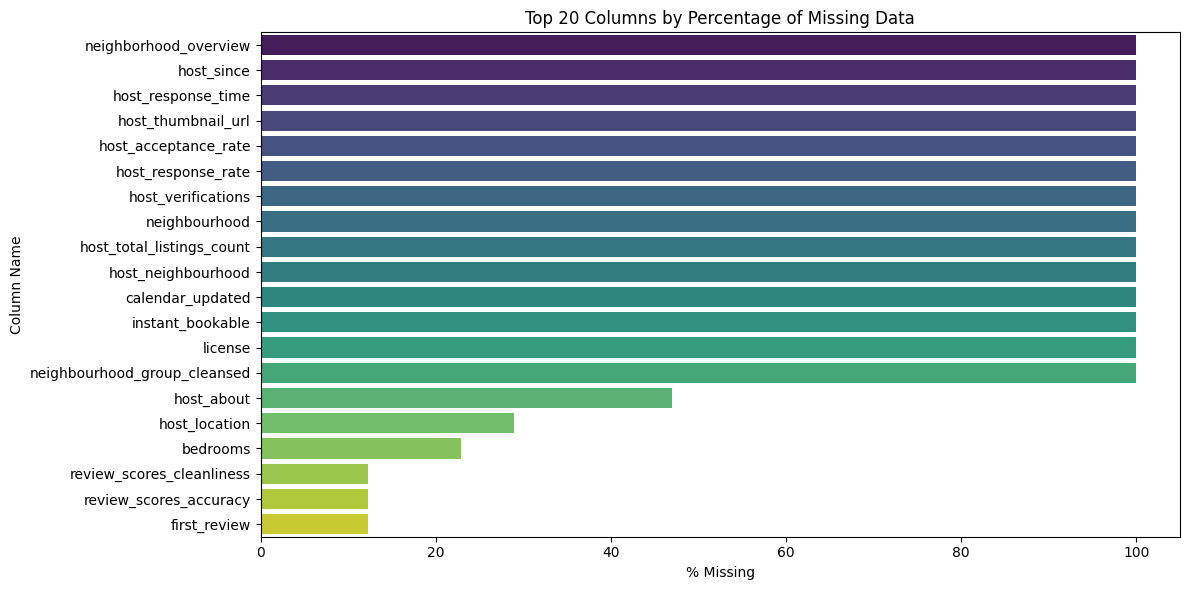

In [12]:
# Add code here 🔧
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame(
    {"Missing Values": missing_counts, "Percent Missing": missing_percent}
).sort_values(by="Percent Missing", ascending=False)

print("Top 15 Columns with Missing Values:")
print(missing_df.head(15))

plt.figure(figsize=(12, 6))
top_missing = missing_df[missing_df["Missing Values"] > 0].head(20)
sns.barplot(
    x=top_missing["Percent Missing"],
    y=top_missing.index,
    palette="viridis",
    hue=top_missing.index,
    legend=False,
)
plt.title("Top 20 Columns by Percentage of Missing Data")
plt.xlabel("% Missing")
plt.ylabel("Column Name")
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1. calendar_updated, license, and neighborhood_overview (along with host_about).

2. Missing numerical rating fields (e.g., review_scores_rating) or financial/capacity details (e.g., bedrooms, beds) cause errors in dynamic pricing engines, automated search ranking algorithms, and revenue projections.

3. Columns with over 80–90% missing values (like calendar_updated or license) or unstructured descriptive text metadata (like neighborhood_overview) can be safely dropped without impacting quantitative models.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [13]:
# Add code here 🔧
columns_to_drop = [
    "calendar_updated",
    "license",
    "neighborhood_overview",
    "host_about",
]

cols_present = [c for c in columns_to_drop if c in df.columns]
df = df.drop(columns=cols_present)

print(f"Dropped columns: {cols_present}")
df.info()

Dropped columns: ['calendar_updated', 'license', 'neighborhood_overview', 'host_about']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 86 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            490 non-null    int64  
 1   listing_url                                   490 non-null    object 
 2   scrape_id                                     490 non-null    int64  
 3   last_scraped                                  490 non-null    object 
 4   source                                        490 non-null    object 
 5   name                                          490 non-null    object 
 6   description                                   481 non-null    object 
 7   picture_url                                   490 non-null    object 
 8   host_id                                       490 no

### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response: 🔧
1. I dropped calendar_updated, license, neighborhood_overview, and host_about.

2. They contained excessive missing values or unstructured narrative text that cannot be directly evaluated by numerical pricing algorithms or quantitative business analytics.

3. Leaving them in would unnecessarily bloat memory usage, clutter data visualisations, and introduce errors or missing value noise into downstream machine learning models.



## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [14]:
# Your code for converting column data types 🔧
if "review_scores_rating" in df.columns:
    median_rating = df["review_scores_rating"].median()
    df["review_scores_rating"] = df["review_scores_rating"].fillna(
        median_rating
    )

if "host_response_time" in df.columns:
    df["host_response_time"] = df["host_response_time"].fillna("Unknown")

print(
    "Remaining nulls in review_scores_rating:",
    df["review_scores_rating"].isnull().sum(),
)
print(
    "Remaining nulls in host_response_time:",
    df["host_response_time"].isnull().sum(),
)

Remaining nulls in review_scores_rating: 0
Remaining nulls in host_response_time: 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response: 🔧
1. I cleaned review_scores_rating and host_response_time.

2. I imputed missing values in review_scores_rating with the dataset's median rating to preserve numerical distribution, and filled missing values in host_response_time with the categorical string "Unknown" to keep records complete without making false assumptions.

3. Filling missing ratings with the median may artificially reduce data variance and overestimate host performance, while labeling missing response times as "Unknown" could distort categorical aggregations or downstream model features.


## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Price column data type: float64

Price Summary Statistics:
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price, dtype: float64


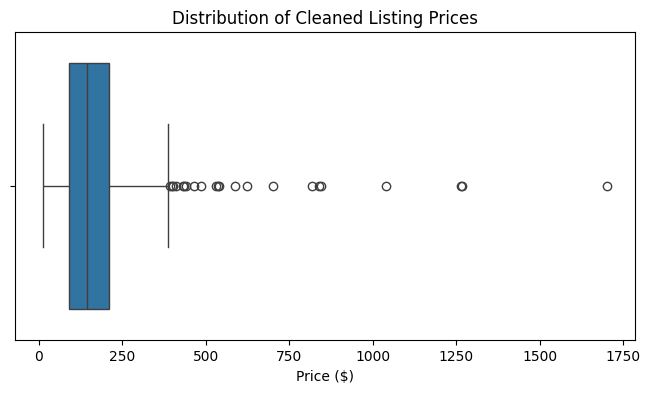

In [15]:
# Clean or adjust your dataset 🔧
if "price" in df.columns and df["price"].dtype == "object":
    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

print("Price column data type:", df["price"].dtype)
print("\nPrice Summary Statistics:")
print(df["price"].describe())

plt.figure(figsize=(8, 4))
sns.boxplot(x=df["price"].dropna())
plt.title("Distribution of Cleaned Listing Prices")
plt.xlabel("Price ($)")
plt.show()

### Reflection: :
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response: 🔧
1. I fixed the price column.

2. I stripped out non-numeric characters, such as dollar signs ($) and commas (,), and converted the values from string objects into floating-point numbers.

3. Converting the pricing data into a numeric data type enables direct mathematical calculations, quantitative aggregation, and seamless ingestion into dynamic pricing models or statistical visualizations.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [16]:
# Add code here 🔧
exact_duplicates = df.duplicated().sum()
id_duplicates = df.duplicated(subset=["id"]).sum()

print(f"Exact row duplicates found: {exact_duplicates}")
print(f"Duplicate listing IDs found: {id_duplicates}")

if id_duplicates > 0:
    df = df.drop_duplicates(subset=["id"], keep="first")
    print("Duplicate IDs removed successfully.")
else:
    print("No duplicate listing IDs found.")

Exact row duplicates found: 0
Duplicate listing IDs found: 0
No duplicate listing IDs found.


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response: 🔧 🔧
1. No exact duplicate rows or duplicate listing IDs were found in the dataset.

2. I checked for duplicate unique identifiers (id) and set the code to keep the first occurrence (keep='first') while dropping any subsequent duplicate records.

3. Duplicates distort key performance metrics, artificially inflate available inventory counts, and can lead to double-counted revenue projections or conflicting host communications.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [17]:
# export csv here 🔧
df.to_csv("cleaned_airbnb_data_6.csv", index=False)
print("Saved successfully as 'cleaned_airbnb_data_6.csv'")

Saved successfully as 'cleaned_airbnb_data_6.csv'


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. Sections 4 and 5 were the most challenging due to data complexity, as deciding how to handle missing numeric values and stripping currency symbols from strings before converting them into float data types required careful data manipulation.
2. I dropped unstructured metadata columns like license and neighborhood_overview because they contained high missingness and low numeric utility, but kept and fixed review_scores_rating via median imputation because listing quality is essential for downstream pricing models.
3. A pricing analyst team benefits directly because non-numeric characters have been removed from prices and missing values have been filled, allowing them to build predictive pricing models without encountering data type or missing-value script errors.
4. If I had more time, I would extract individual features from the JSON-formatted amenities column into binary indicator flags (such as has_wifi or allows_pets) and check for extreme pricing outliers.
5. This assignment aligns with my learning outcome of mastering real-world data preparation workflows by taking unstructured, messy web data and systematically auditing, cleaning, and exporting it for downstream business intelligence pipelines.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [18]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_06_data_cleaning.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru